In [1]:
import kagglehub
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'wine-quality-dataset' dataset.
Path to dataset files: /kaggle/input/wine-quality-dataset


In [2]:
import pandas as pd
df=pd.read_csv(path+"/WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:

df.info()

df.isnull().sum()

df["quality"].value_counts().sort_index()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


,count
quality,
3,6
4,33
5,483
6,462
7,143
8,16


In [4]:
df.drop("Id", axis=1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6


In [5]:
df.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


This correlation step is much necessary in this project.
it associates each feature with the quality of wine.

for example: Alcohol has +0.48 , which means higher alcohol content is will likely lead to better wine quality etc.

pH almost has no relationahip because it value is near to '0' which means it doesnt have much effect on the wine quality.Based on these correlations we get the data required to be used for model.

In [6]:
df.drop("Id", axis=1).corr()["quality"].sort_values(ascending=False)

,quality
quality,1.000000
alcohol,0.484866
sulphates,0.257710
citric acid,0.240821
fixed acidity,0.121970
residual sugar,0.022002
pH,-0.052453
free sulfur dioxide,-0.063260
chlorides,-0.124085
density,-0.175208


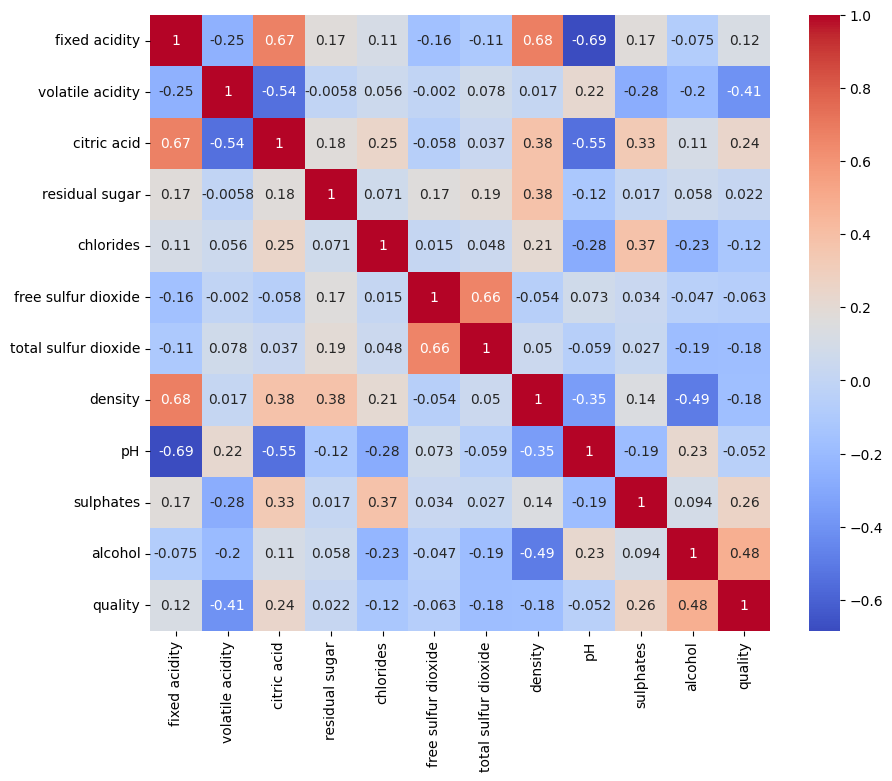

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop("Id", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

looking out for the outliners which interrupt the accuracy of model.


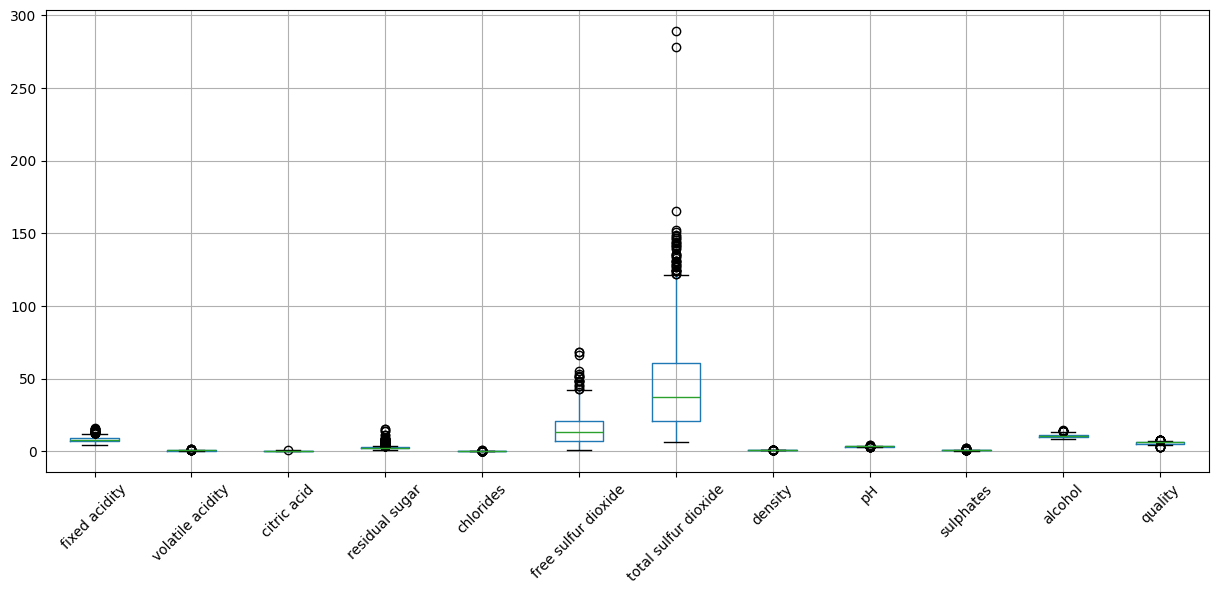

In [8]:
import matplotlib.pyplot as plt

df.drop("Id", axis=1).boxplot(
    figsize=(15,6),
    rot=45
)

plt.show()

No need to take out all the outliners because models like decision forest , random forest are robust for outliners

In [9]:
X = df.drop(["quality", "Id"], axis=1)

y = df["quality"]

print(X.shape)
print(y.shape)

(1143, 11)
(1143,)


Split the data for training and testing

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (914, 11)
X_test : (229, 11)
y_train: (914,)
y_test : (229,)


understand the base-line with regression though we are not using it for actual fitting

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=5000
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

In [13]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train Accuracy:", train_score)
print("Test Accuracy :", test_score)

Train Accuracy: 0.5962800875273523
Test Accuracy : 0.6244541484716157


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression

scaled_model = LogisticRegression(
    max_iter=5000
)

scaled_model.fit(
    X_train_scaled,
    y_train
)

print(
    "Train:",
    scaled_model.score(X_train_scaled, y_train)
)

print(
    "Test:",
    scaled_model.score(X_test_scaled, y_test)
)

Train: 0.6072210065645515
Test: 0.6244541484716157


Logistic Regression tries to learn fairly simple decision boundaries something like:

If alcohol is high
and volatile acidity is low
then quality is higher

But wine chemistry is probably more complicated.

Real relationships may look like:

Alcohol + Sulphates interaction

Citric Acid + pH interaction

Non-linear effects

Logistic Regression struggles with such complexity

Lets create a confusion matrix to see what the model has learnt in each class

In [16]:
from sklearn.metrics import confusion_matrix

y_pred = scaled_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 0  0  1  0  0  0]
 [ 0  0  4  3  0  0]
 [ 0  0 76 19  2  0]
 [ 0  0 25 58  8  1]
 [ 0  0  2 18  9  0]
 [ 0  0  0  1  2  0]]


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.70      0.78      0.74        97
           6       0.59      0.63      0.61        92
           7       0.43      0.31      0.36        29
           8       0.00      0.00      0.00         3

    accuracy                           0.62       229
   macro avg       0.29      0.29      0.28       229
weighted avg       0.59      0.62      0.60       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Suppose the model predicts:
Quality 3 = 0 times
Then precision becomes:
TP/FP+TP
But:
TP = 0
FP = 0
which becomes:
0/0 -Undefined.
So sklearn reports:
precision = 0
and gives a warning.**

Logistic Regression just simply learns relationships but decision trees or randpm forests actually intercats with the features because the actual wine quality is influenced by acombinations of all the features.
Lets try to find the accuracy with **Random Forests**.

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

train_score = rf.score(X_train, y_train)
test_score = rf.score(X_test, y_test)

print("Train Accuracy:", train_score)
print("Test Accuracy :", test_score)

Train Accuracy: 1.0
Test Accuracy : 0.7161572052401747


We can se that train score is 100% which means this lead to overfitting, but random forests did well that regression as accuracy has significantly improved.

the overfitting was because the tree was keep on growing and was becoming too complex , so we have to limit this tree growth.
lets see what random forest think important features are:

In [19]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

feature_importance.sort_values(
    by="importance",
    ascending=False
)

,feature,importance
10,alcohol,0.150212
9,sulphates,0.115907
1,volatile acidity,0.106638
6,total sulfur dioxide,0.097958
7,density,0.087983
4,chlorides,0.078689
0,fixed acidity,0.077977
2,citric acid,0.077131
8,pH,0.077033
3,residual sugar,0.065486


**ChatGPT says:** Correlation asks

"How strongly is this feature related to quality by itself?"

Random Forest Importance asks

"How much does this feature help me make better decisions inside the forest?"

Lets evaluate random forest rpoperly:

In [20]:
from sklearn.metrics import classification_report

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.74      0.85      0.79        97
           6       0.69      0.74      0.71        92
           7       0.74      0.48      0.58        29
           8       0.00      0.00      0.00         3

    accuracy                           0.72       229
   macro avg       0.36      0.34      0.35       229
weighted avg       0.68      0.72      0.69       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


not good with quality 3,4,8 so lets balance so that model pays attention to quality 3,4,8

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_balanced.fit(X_train, y_train)

y_pred_balanced = rf_balanced.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_balanced
))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.70      0.80      0.75        97
           6       0.63      0.66      0.65        92
           7       0.74      0.48      0.58        29
           8       1.00      0.33      0.50         3

    accuracy                           0.67       229
   macro avg       0.51      0.38      0.41       229
weighted avg       0.65      0.67      0.66       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [23]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

In [24]:
rf = RandomForestClassifier(
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

In [25]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'class_weight': [None, 'balanced'],
                                        'max_depth': [5, 10, 15, 20, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1_weighted')

In [26]:
print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'class_weight': 'balanced'}
0.6374576638949618


In [27]:
best_rf = random_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

In [28]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_best
))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.75      0.81      0.78        97
           6       0.67      0.73      0.70        92
           7       0.68      0.52      0.59        29
           8       1.00      0.33      0.50         3

    accuracy                           0.71       229
   macro avg       0.52      0.40      0.43       229
weighted avg       0.68      0.71      0.69       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
print(
    "Test Accuracy:",
    best_rf.score(X_test, y_test)
)

Test Accuracy: 0.7074235807860262


due to the imbalance of the data it might be misleading to predict quality 3-8 for wine, instead we can say it as good quality or poor quality wine

In [30]:
df["quality_label"] = (
    df["quality"] >= 6
).astype(int)

df["quality_label"].value_counts()

,count
quality_label,
1,621
0,522


In [31]:
X = df.drop(
    ["quality", "quality_label", "Id"],
    axis=1
)

y = df["quality_label"]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

As we thought of binary prediction lets see how regression works

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

In [35]:
print(
    "Train Accuracy:",
    lr.score(X_train_scaled, y_train)
)

print(
    "Test Accuracy:",
    lr.score(X_test_scaled, y_test)
)

Train Accuracy: 0.7636761487964989
Test Accuracy: 0.777292576419214


In [36]:
from sklearn.metrics import classification_report

y_pred = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.77      0.76       105
           1       0.80      0.78      0.79       124

    accuracy                           0.78       229
   macro avg       0.78      0.78      0.78       229
weighted avg       0.78      0.78      0.78       229



In [37]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[81 24]
 [27 97]]


In [38]:
import joblib

joblib.dump(lr, "wine_binary_model.pkl")
joblib.dump(scaler, "wine_scaler.pkl")

['wine_scaler.pkl']

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_binary = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_binary.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [40]:
print(
    "Train Accuracy:",
    rf_binary.score(X_train, y_train)
)

print(
    "Test Accuracy:",
    rf_binary.score(X_test, y_test)
)

Train Accuracy: 1.0
Test Accuracy: 0.8034934497816594


In [41]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

y_pred_rf = rf_binary.predict(X_test)

print(classification_report(
    y_test,
    y_pred_rf
))

print(confusion_matrix(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.81      0.75      0.78       105
           1       0.80      0.85      0.82       124

    accuracy                           0.80       229
   macro avg       0.80      0.80      0.80       229
weighted avg       0.80      0.80      0.80       229

[[ 79  26]
 [ 19 105]]


In [42]:
pip install shap

In [43]:
import shap

explainer = shap.TreeExplainer(rf_binary)

shap_values = explainer.shap_values(X_test)

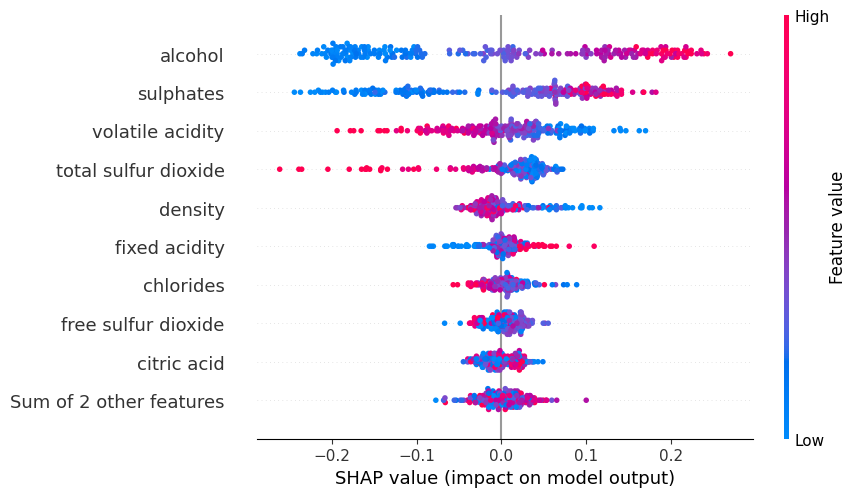

In [45]:
shap.plots.beeswarm(
    shap.Explanation(
        values=shap_values[:,:,1],
        data=X_test,
        feature_names=X.columns
    )
)

In [46]:
joblib.dump(rf_binary, "wine_binary_model.pkl")

['wine_binary_model.pkl']

In [47]:
import joblib

model = joblib.load(
    "wine_binary_model.pkl"
)

In [48]:
def predict_wine(features):
    prediction = model.predict([features])[0]

    probability = model.predict_proba(
        [features]
    )[0]

    return prediction, probability

test


In [49]:
sample_wine = [
    7.4,   # fixed acidity
    0.50,  # volatile acidity
    0.30,  # citric acid
    2.1,   # residual sugar
    0.07,  # chlorides
    15,    # free sulfur dioxide
    35,    # total sulfur dioxide
    0.996, # density
    3.3,   # pH
    0.75,  # sulphates
    12.0   # alcohol
]

In [51]:
prediction = model.predict(
    [sample_wine]
)[0]

probability = model.predict_proba(
    [sample_wine]
)[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [52]:
print("Prediction:", prediction)
print("Probabilities:", probability)

Prediction: 1
Probabilities: [0.06 0.94]


In [53]:
def predict_wine(wine_features):

    prediction = model.predict(
        wine_features
    )[0]

    probability = model.predict_proba(
        wine_features
    )[0]

    label = (
        "High Quality"
        if prediction == 1
        else "Low Quality"
    )

    confidence = max(probability)

    return {
        "prediction": label,
        "confidence": round(
            confidence * 100,
            2
        )
    }

Just download the model to use it..

In [55]:
from google.colab import files

files.download("wine_binary_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>